# Praktikum 1

In this praktikum we will learn to implement image enhancement from module 3

## Install Dependencies

In [16]:
# pip install opencv-python numpy matplotlib jupyter ipywidgets

## Import Required Libraries

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, FloatSlider, Checkbox  # this is for interactivity

In [18]:
# import the image we will use in this tutorial
zelda_img = cv2.imread("zelda.png")

## Point Operation

**Contrast Stretching using CV2 library**

The code below shows how to stretching the contrast of an image by using $\alpha$ and $\beta$ value.

Observe how those values affect the looks of the image! 

In [19]:
@interact(alpha=(0, 255, 5), beta=(0, 255, 5))
def constrast_stretching(
        alpha=100,
        beta=200,
    ):
    
    stretched_img = cv2.normalize(zelda_img, None, alpha, beta, norm_type=cv2.NORM_MINMAX)

    # 1. Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(zelda_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Stretched Image
    plt.subplot(2, 2, 2)
    plt.imshow(stretched_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Piecewise Stretched")
    plt.axis('off')
    
    # 3. Original Histogram
    plt.subplot(2, 2, 3)
    plt.hist(zelda_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Original Histogram")
    plt.xlim([0, 256])
    
    # 4. Stretched Histogram
    plt.subplot(2, 2, 4)
    plt.hist(stretched_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Stretched Histogram")
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=100, description='alpha', max=255, step=5), IntSlider(value=200, descrip…

**Applying Treshold Value using CV2 library**

The code below shows how to apply the binary treshold to an image by setting the treshold/limit and the maximum value to apply to.

Observe how those values affect the looks of the image!

Can you connect the equation below to the code?

$$y = \begin{cases} 0 & 0 \le x < a \\ 1 & a \le x < L \end{cases}$$

In [20]:
@interact(treshold_value=(0, 255, 5), max_value=(0,255,5))
def constrast_stretching(
        treshold_value=100,
        max_value=255,
    ):

    _, thresholded_cv = cv2.threshold(zelda_img, treshold_value, max_value, cv2.THRESH_BINARY)

    # 1. Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(zelda_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Stretched Image
    plt.subplot(2, 2, 2)
    plt.imshow(thresholded_cv, cmap='gray', vmin=0, vmax=255)
    plt.title("Treshold Image")
    plt.axis('off')
    
    # 3. Original Histogram
    plt.subplot(2, 2, 3)
    plt.hist(zelda_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Original Histogram")
    plt.xlim([0, 256])
    
    # 4. Stretched Histogram
    plt.subplot(2, 2, 4)
    plt.hist(thresholded_cv.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Treshold Histogram")
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=100, description='treshold_value', max=255, step=5), IntSlider(value=255…

**Applying Clipping to an Image**

Somtimes we want more control of each pixels. For this, we could use Numpy. Guess what? OpenCV uses Numpy array.

The code below is just applying the this math by using "masking" in Numpy array.

$$
    y = \begin{cases}
            0 & 0 \le x < a \\
            \beta(x-a) & a \le x < b \\
            \beta(b-a) & b \le x < L
        \end{cases}
$$

To understand the code we can recall this plot.

![Stretching Curve](stretching_curve.png)

In [21]:
@interact(a=(0, 255, 5), b=(0, 255, 5))
def apply_clipping(a=80, b=170):
    # Prevent divide-by-zero errors and ensure a is strictly less than b
    if a >= b:
        b = a + 1
        
    x = zelda_img.astype(float)
    y = np.zeros_like(x)
    
    L = 255
    
    # Calculate the slope (beta) to stretch the middle region from 0 to 255
    beta = L / (b - a)
    
    # Convert input to float for math operations
    
    # 1. Lower clipping (0 <= x < a) -> Map to 0
    mask1 = (x >= 0) & (x < a)
    y[mask1] = 0
    
    # 2. Scaled response (a <= x < b) -> Apply beta slope
    mask2 = (x >= a) & (x < b)
    y[mask2] = beta * (x[mask2] - a)
    
    # 3. Upper clipping (b <= x < L) -> Map to constant upper level
    mask3 = (x >= b)
    y[mask3] = beta * (b - a) # This mathematically equals 255 based on our beta
    
    # Convert back to uint8
    clipped_img = np.clip(y, 0, L).astype(np.uint8)

    # --- SHOW IMAGES AND HISTOGRAMS ---
    plt.figure(figsize=(14, 8))
    
    # 1. Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(zelda_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Clipped Image
    plt.subplot(2, 2, 2)
    plt.imshow(clipped_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Clipped Image")
    plt.axis('off')
    
    # 3. Original Histogram
    plt.subplot(2, 2, 3)
    plt.hist(zelda_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Original Histogram")
    plt.xlim([0, 256])
    
    # 4. Clipped Histogram
    plt.subplot(2, 2, 4)
    plt.hist(clipped_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title(f"Clipped Histogram (a={a}, b={b})")
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=80, description='a', max=255, step=5), IntSlider(value=170, description=…

**Tresholding Via Gamma Correction $\gamma > 1$**

The application on gamma correction uses in video game. The developer wanted the game to look more scary by suppressing the bright part. ie. Resident Evil 4 Remake.

Instead of using Numpy, we can also map the pixel values using Look Up Table (LUT) using OpenCV library.

In [ ]:
@interact(gamma=(0.04, 5, 0.1))
def tresholding_gamma_correction(
    gamma=1.5
):    
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8")
    gamma_corrected = cv2.LUT(zelda_img, table)

    # --- SHOW IMAGES AND HISTOGRAMS ---
    plt.figure(figsize=(14, 8))
    
    # 1. Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(zelda_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Clipped Image
    plt.subplot(2, 2, 2)
    plt.imshow(gamma_corrected, cmap='gray', vmin=0, vmax=255)
    plt.title("Corrected Image")
    plt.axis('off')
    
    # 3. Original Histogram
    plt.subplot(2, 2, 3)
    plt.hist(zelda_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Original Histogram")
    plt.xlim([0, 256])
    
    # 4. Clipped Histogram
    plt.subplot(2, 2, 4)
    plt.hist(gamma_corrected.ravel(), bins=256, range=[0, 256], color='black')
    plt.title(f"Corrected Histogram")
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=1.5, description='gamma', max=5.0, min=0.04), Output()), _dom_classes=…

## Image Negative

This is probably the easiest operation since we can subtract numpy array or using bitwise not operation like the code below.

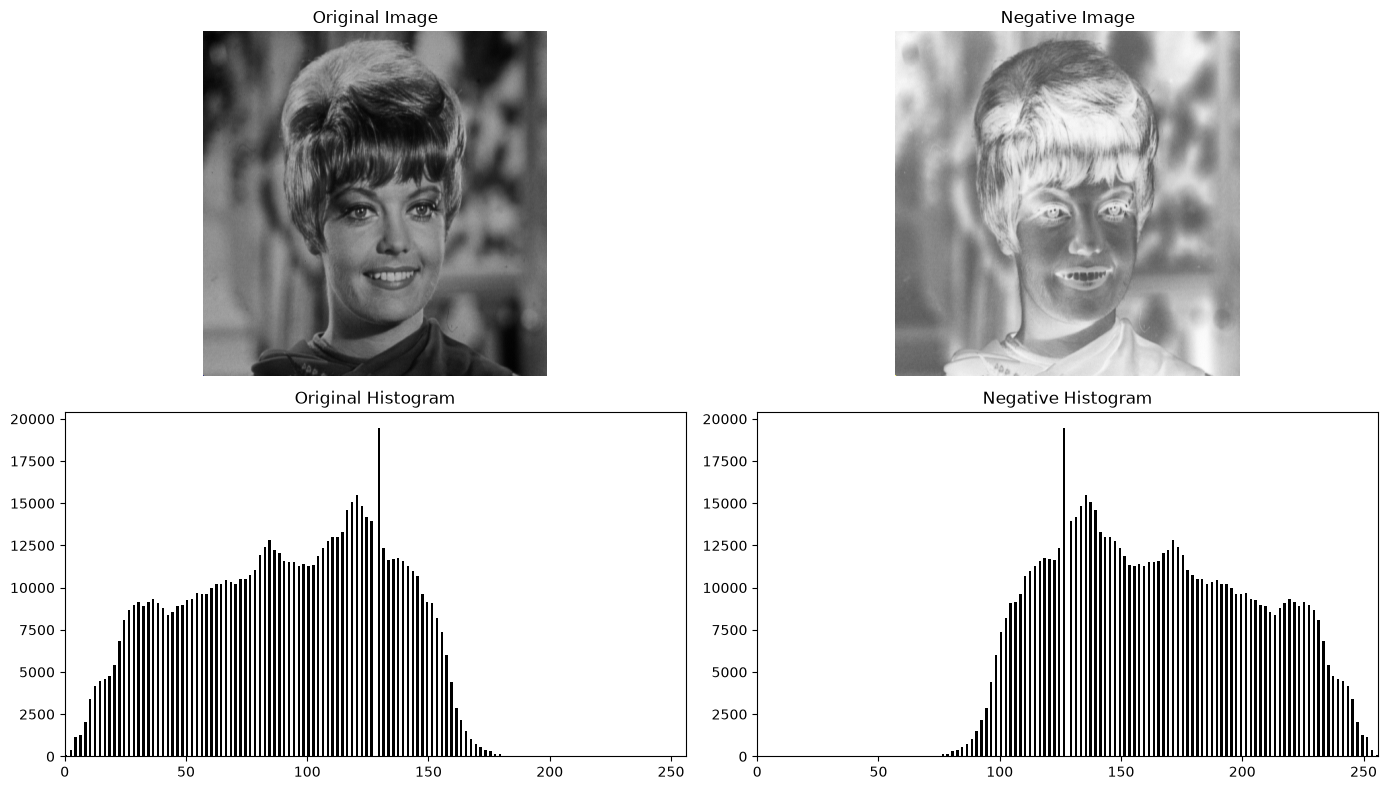

In [23]:
def image_negative():    
    negative_img = cv2.bitwise_not(zelda_img)

    # Numpy Array can do element wise operation
    # what the code will be?
    # your negative image = max_pixel_value - your positive image

    # --- SHOW IMAGES AND HISTOGRAMS ---
    plt.figure(figsize=(14, 8))
    
    # 1. Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(zelda_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Clipped Image
    plt.subplot(2, 2, 2)
    plt.imshow(negative_img, cmap='gray', vmin=0, vmax=255)
    plt.title("Negative Image")
    plt.axis('off')
    
    # 3. Original Histogram
    plt.subplot(2, 2, 3)
    plt.hist(zelda_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Original Histogram")
    plt.xlim([0, 256])
    
    # 4. Clipped Histogram
    plt.subplot(2, 2, 4)
    plt.hist(negative_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title(f"Negative Histogram")
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

image_negative()

## Window Slicing

Since OpenCV does not have a dedicated function for this operation we can either use LUT or Numpy operation to do this. Let's recall the math!

Without background
$$
    v = \begin{cases}
            L & a \le u \le b \\
            0 & otherwise
        \end{cases}
$$

With background
$$
    v = \begin{cases}
            L & a \le u \le b \\
            u & otherwise
        \end{cases}
$$




In [24]:
@interact(a=(0, 255, 5), b=(0, 255, 5), keep_background=Checkbox(value=False, description='With Background'))
def apply_window_slicing(a=80, b=150, keep_background=False):
    # Prevent logical errors if sliders cross
    if a >= b:
        b = a + 1
        
    L = 255
    u = cv2.imread("aortic.png", cv2.IMREAD_GRAYSCALE)
    
    # 1. Create the boolean mask for our target window
    in_window = (u >= a) & (u <= b)
    
    # 2. Apply the mathematical logic from the slide
    if keep_background:
        # "With background" -> If in window, set to L. Otherwise, keep original 'u'
        v = np.where(in_window, L, u)
    else:
        # "Without background" -> If in window, set to L. Otherwise, set to 0
        v = np.where(in_window, L, 0)
        
    # Convert back to standard 8-bit image format
    sliced_img = v.astype(np.uint8)

    # --- SHOW IMAGES AND HISTOGRAMS ---
    plt.figure(figsize=(14, 8))
    
    # 1. Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(u, cmap='gray', vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Sliced Image
    plt.subplot(2, 2, 2)
    plt.imshow(sliced_img, cmap='gray', vmin=0, vmax=255)
    title_text = "With Background" if keep_background else "Without Background"
    plt.title(f"Window Slicing ({title_text})")
    plt.axis('off')
    
    # 3. Original Histogram
    plt.subplot(2, 2, 3)
    plt.hist(u.ravel(), bins=256, range=[0, 256], color='black')
    plt.axvline(x=a, color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(x=b, color='red', linestyle='dashed', linewidth=1)
    plt.title("Original Histogram")
    plt.xlim([0, 256])
    
    # 4. Sliced Histogram
    plt.subplot(2, 2, 4)
    plt.hist(sliced_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title("Sliced Histogram")
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=80, description='a', max=255, step=5), IntSlider(value=150, description=…

## Histogram Equalization

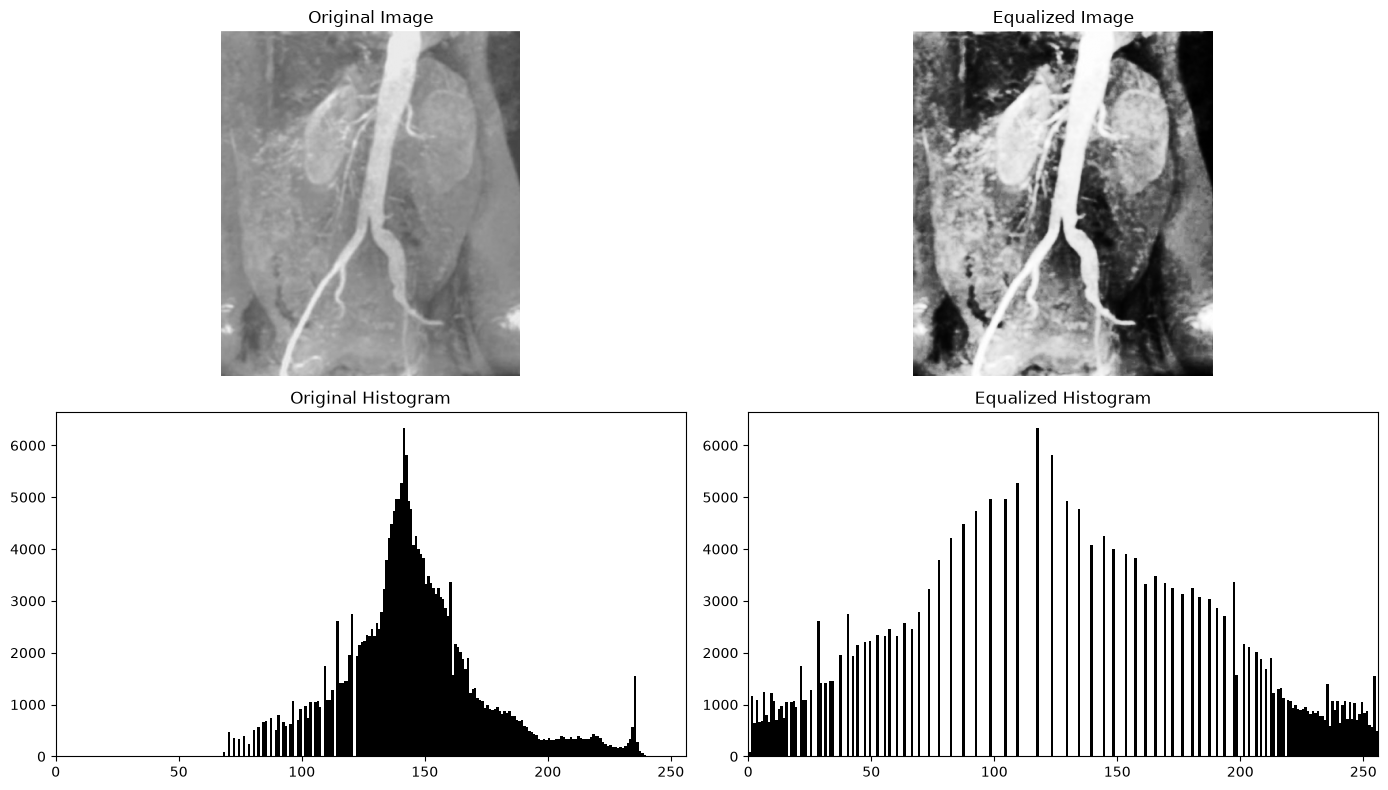

In [ ]:
img = cv2.imread("aortic.png", cv2.IMREAD_GRAYSCALE)

# equalized_img = # Find the OpenCV function!

# --- SHOW IMAGES AND HISTOGRAMS ---
plt.figure(figsize=(14, 8))

# 1. Original Image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

# 2. Equalized
plt.subplot(2, 2, 2)
plt.imshow(equalized_img, cmap='gray', vmin=0, vmax=255)
plt.title(f"Equalized Image")
plt.axis('off')

# 3. Original Histogram
plt.subplot(2, 2, 3)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black')
plt.title("Original Histogram")
plt.xlim([0, 256])

# 4. Equalized Histogram
plt.subplot(2, 2, 4)
plt.hist(equalized_img.ravel(), bins=256, range=[0, 256], color='black')
plt.title("Equalized Histogram")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## Spatial Operation

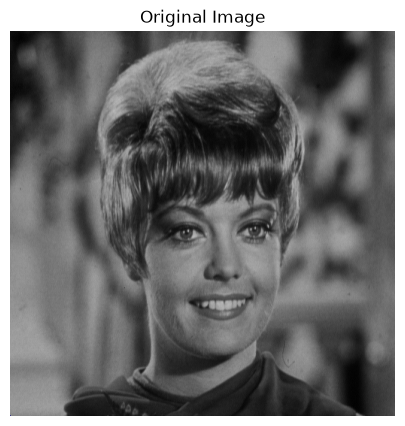

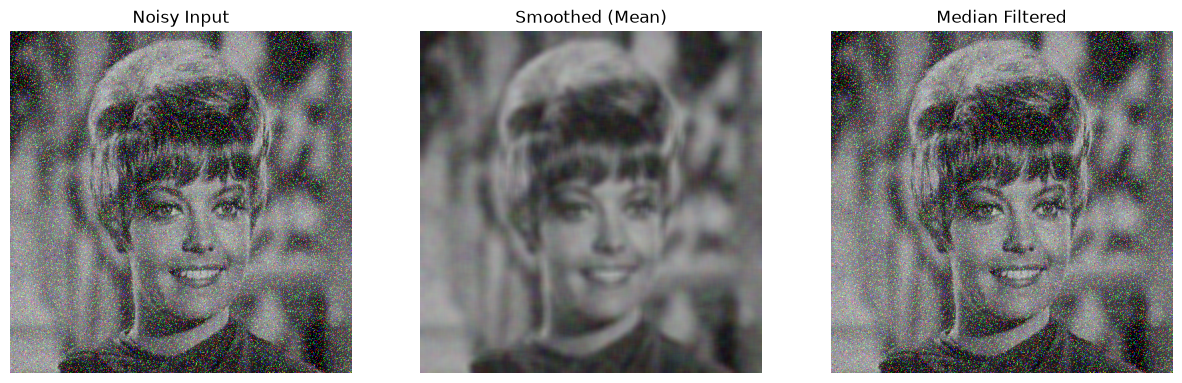

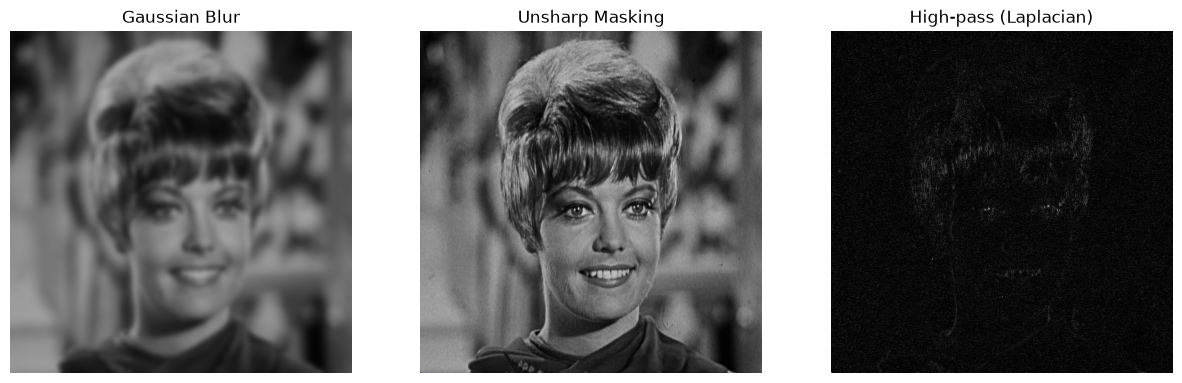

In [ ]:
def show_images(titles, images, cmap='gray'):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        # Added vmin and vmax to ensure Matplotlib doesn't auto-adjust the brightness incorrectly
        plt.imshow(images[i], cmap=cmap if len(images[i].shape) == 2 else None, vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# --- 1. Create a Noisy Version of Zelda ---
# Generate random noise and add it to the image (Salt and Pepper style)
noise = np.random.randint(0, 10, zelda_img.shape, dtype=np.uint8) * 255

# Randomly apply the noise to 5% of the pixels
noise_mask = np.random.rand(*zelda_img.shape) < .1
noisy_zelda = zelda_img.copy()
noisy_zelda[noise_mask] = noise[noise_mask]

# --- 2. Apply Filters to the NOISY Image ---
# 2.1 Noise Smoothing (Average Blur)
# Adjust the kernel size and see the effect!
kernel = (12, 12)
smoothed = cv2.blur(noisy_zelda, kernel)

# 2.2 Median Filtering
# Find a good kernel size to remove the noise!
kernel = 1
median_filtered = cv2.medianBlur(noisy_zelda, kernel)

# --- 3. Apply Edge Enhancement to the ORIGINAL Image ---
# the kernel size must be odd!
# change the variables here what could go wrong?
gaussian_blur = cv2.GaussianBlur(zelda_img, (21, 21), 0)
unsharp_mask = cv2.addWeighted(zelda_img, 1.5, gaussian_blur, -0.5, 0)

# 2.4 High-pass Filtering (Laplacian)
laplacian_high_pass = cv2.Laplacian(zelda_img, cv2.CV_64F)
laplacian_high_pass = cv2.convertScaleAbs(laplacian_high_pass)

# --- SHOW RESULTS ---
show_images(['Original Image'], [zelda_img])
show_images(['Noisy Input', 'Smoothed (Mean)', 'Median Filtered'], [noisy_zelda, smoothed, median_filtered])
show_images(['Gaussian Blur', 'Unsharp Masking', 'High-pass (Laplacian)'], [gaussian_blur, unsharp_mask, laplacian_high_pass])

## Frequency Domain Response

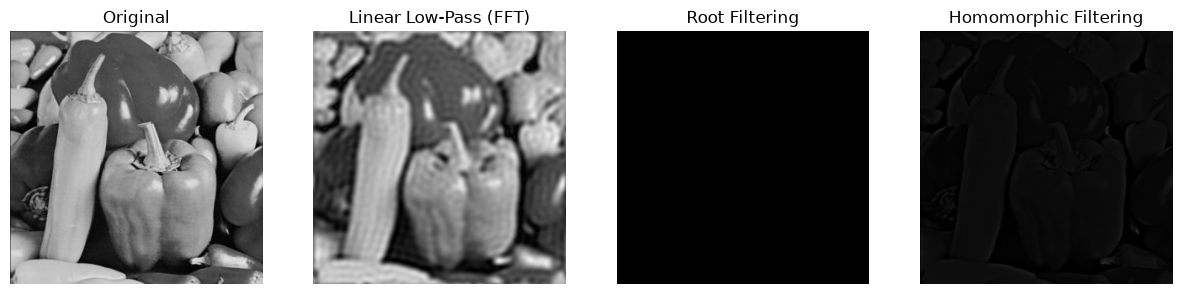

In [ ]:
# Compute FFT
sample_img = cv2.imread("peppers.jpg", cv2.IMREAD_GRAYSCALE)

f = np.fft.fft2(sample_img)
fshift = np.fft.fftshift(f)
rows, cols = sample_img.shape
crow, ccol = rows//2, cols//2

# 3.1 Linear Filtering (Ideal Low Pass Filter in Frequency Domain)
mask = np.zeros((rows, cols), np.uint8)
r = 30 # radius
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0])**2 + (y - center[1])**2 <= r*r
mask[mask_area] = 1
fshift_filtered = fshift * mask
img_back_linear = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtered)))

# 3.2 Root Filtering (Square root of magnitude, preserve phase)
magnitude = np.abs(fshift)
phase = np.angle(fshift)
root_magnitude = np.sqrt(magnitude)
fshift_root = root_magnitude * np.exp(1j * phase)
img_back_root = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_root)))

# 3.3 Homomorphic Filtering (Simplified)
# log(I) -> FFT -> High Frequency Emphasis -> IFFT -> exp(I)
img_log = np.log1p(np.array(sample_img, dtype="float"))
f_log = np.fft.fft2(img_log)
fshift_log = np.fft.fftshift(f_log)

# Create a High Frequency Emphasis Filter (Gaussian-based)
D = np.sqrt((x - crow)**2 + (y - ccol)**2)
D0 = 10.0
gamma_H, gamma_L = 1.2, 0.5
H = (gamma_H - gamma_L) * (1 - np.exp(-(D**2)/(2*(D0**2)))) + gamma_L

fshift_homo = fshift_log * H
img_back_homo = np.expm1(np.real(np.fft.ifft2(np.fft.ifftshift(fshift_homo))))

show_images(['Original', 'Linear Low-Pass (FFT)', 'Root Filtering', 'Homomorphic Filtering'], [sample_img, img_back_linear, img_back_root, img_back_homo])

## Edge Detection

Applying edge detection is easy because OpenCV have dedicated function for them.

**Sobel Edge Detection**

In [ ]:
@interact(kernelSize=(3,21,2))
def sobel_edge_detection(
    kernelSize=3
):
    # ==========================================
    # 1. SOBEL (Gradient-based Edge Detection)
    # ==========================================
    # Sobel acts as a directional high-pass filter. 
    # We have to calculate the vertical edges (X) and horizontal edges (Y) separately.
    sobel_x = cv2.Sobel(sample_img, cv2.CV_64F, 1, 0, ksize=kernelSize) # Detects vertical lines
    sobel_y = cv2.Sobel(sample_img, cv2.CV_64F, 0, 1, ksize=kernelSize) # Detects horizontal lines

    # Convert the mathematical gradients back to 8-bit image pixels
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)

    # Combine the X and Y gradients to get the full edge map
    sobel_combined = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

    # --- SHOW RESULTS ---
    show_images(['Original', 'Sobel X (Verticals)', 'Sobel Y (Horizontals)', 'Sobel Combined'], 
                [sample_img, abs_sobel_x, abs_sobel_y, sobel_combined])

interactive(children=(IntSlider(value=3, description='kernelSize', max=21, min=3, step=2), Output()), _dom_cla…

**Canny Edge Detection**

In [ ]:
@interact(lower_thresh=(0,255,5), upper_thresh=(0,255,5))
def canny_edge_detection(
    lower_thresh=80,
    upper_thresh=170,      
):
    # ==========================================
    # 2. CANNY (The Industry Standard)
    # ==========================================
    # Canny is highly sensitive to high-frequency noise. 
    # Therefore, we ALWAYS apply a low-pass filter (Gaussian Blur) first!
    blurred_for_canny = cv2.GaussianBlur(sample_img, (5, 5), 0)

    # cv2.Canny takes a lower and upper threshold for its internal hysteresis logic.
    # Try to change the treshold values!
    canny_edges = cv2.Canny(blurred_for_canny, lower_thresh, upper_thresh)

    show_images(['Blurred Image', 'Canny Edges'], 
                [blurred_for_canny, canny_edges])

interactive(children=(IntSlider(value=80, description='lower_thresh', max=255, step=5), IntSlider(value=170, d…

## Lets have fun!

Make this photo to look **HORROR** using what you've practice so far! IYKWIM, huehue.

![Zelda](zelda.png)

*put your code below*